In [1]:
import torch
import torch.nn as nn
import pickle
import json
from torch.utils.data import DataLoader

from src.classifier import Classifier
from src.trainer import Trainer
from src.datasets_classes import MultiDomainDataset, multidomain_collate_fn
from src.utils.evaluation import compute_classification_reports, save_confusion_matrices

c:\Users\alice\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("outputs/models/fitted_pcas.pkl", "rb") as f:
    fitted_pcas = pickle.load(f)

In [3]:
test_dataset = MultiDomainDataset("outputs/embeddings/test")

In [4]:
for domain_name in test_dataset.domain_data:
    test_embeddings = test_dataset.domain_data[domain_name]["embedding"]
    if isinstance(test_embeddings, torch.Tensor):
        test_embeddings = test_embeddings.numpy()

    test_reduced = fitted_pcas[domain_name].transform(test_embeddings)
    test_dataset.domain_data[domain_name]["embedding"] = torch.tensor(test_reduced, dtype=torch.float32)

In [5]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=multidomain_collate_fn)

In [6]:
checkpoint = torch.load("outputs/models/best_model.pt", map_location=torch.device("cpu"))


projectors = nn.ModuleDict({domain: nn.Identity() for domain in checkpoint["input_dims"]})
classifier = Classifier(shared_dim=checkpoint["shared_dim"], hidden_dim = checkpoint["hidden_dim"], dropout=checkpoint["dropout"])

projectors.load_state_dict(checkpoint["projectors_state_dict"])
classifier.load_state_dict(checkpoint["classifier_state_dict"])

trainer = Trainer(projectors, classifier, shared_dim=checkpoint["shared_dim"])

In [10]:
import pandas as pd
from IPython.display import display

def display_classification_reports(reports):
    for split_name, split_data in reports.items():
        print(f"\n {split_name} — overall")
        overall_df = pd.DataFrame(split_data["overall"]).transpose()
        display(overall_df)

        for domain, domain_report in split_data["domains"].items():
            print(f"\n {split_name} — {domain}")
            domain_df = pd.DataFrame(domain_report).transpose()
            display(domain_df)

In [11]:
splits = [("test", test_loader)]
reports = compute_classification_reports(trainer, splits)
display_classification_reports(reports)

with open("outputs/tables/test_classification_report.json", "w") as f:
    json.dump(reports, f, indent=2)


 test — overall


,precision,recall,f1-score,support
0,0.954421,0.928915,0.941495,1871.000000
1,0.791536,0.858844,0.823817,588.000000
accuracy,0.912159,0.912159,0.912159,0.912159
macro avg,0.872978,0.893879,0.882656,2459.000000
weighted avg,0.915471,0.912159,0.913356,2459.000000
balanced_accuracy,0.893879,0.893879,0.893879,0.893879



 test — animal


,precision,recall,f1-score,support
0,0.903226,0.933333,0.918033,240.000000
1,0.714286,0.625000,0.666667,64.000000
accuracy,0.868421,0.868421,0.868421,0.868421
macro avg,0.808756,0.779167,0.792350,304.000000
weighted avg,0.863449,0.868421,0.865114,304.000000
balanced_accuracy,0.779167,0.779167,0.779167,0.779167



 test — music


,precision,recall,f1-score,support
0,0.540541,0.952381,0.689655,21.000000
1,0.975000,0.696429,0.812500,56.000000
accuracy,0.766234,0.766234,0.766234,0.766234
macro avg,0.757770,0.824405,0.751078,77.000000
weighted avg,0.856511,0.766234,0.778997,77.000000
balanced_accuracy,0.824405,0.824405,0.824405,0.824405



 test — soundscapes


,precision,recall,f1-score,support
0,0.702128,0.540984,0.611111,61.000000
1,0.626667,0.770492,0.691176,61.000000
accuracy,0.655738,0.655738,0.655738,0.655738
macro avg,0.664397,0.655738,0.651144,122.000000
weighted avg,0.664397,0.655738,0.651144,122.000000
balanced_accuracy,0.655738,0.655738,0.655738,0.655738



 test — speech


,precision,recall,f1-score,support
0,0.981195,0.943189,0.961817,1549.000000
1,0.811563,0.931204,0.867277,407.000000
accuracy,0.940695,0.940695,0.940695,0.940695
macro avg,0.896379,0.937197,0.914547,1956.000000
weighted avg,0.945899,0.940695,0.942145,1956.000000
balanced_accuracy,0.937197,0.937197,0.937197,0.937197


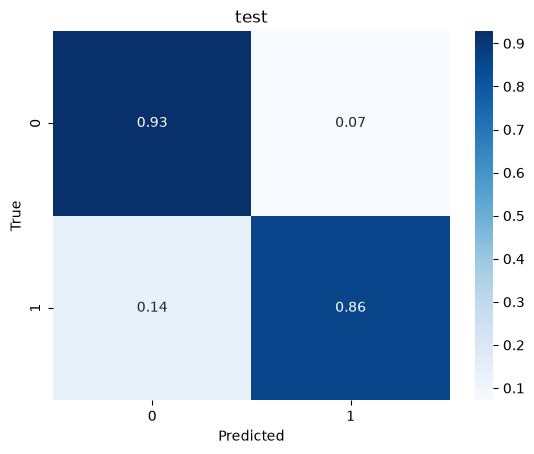

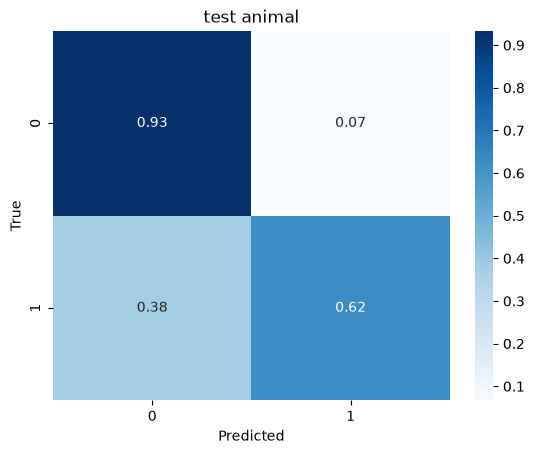

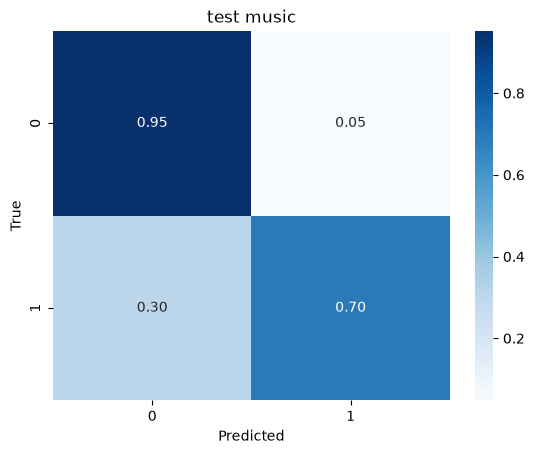

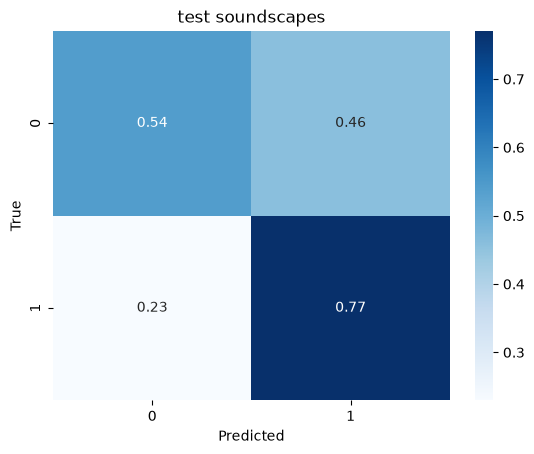

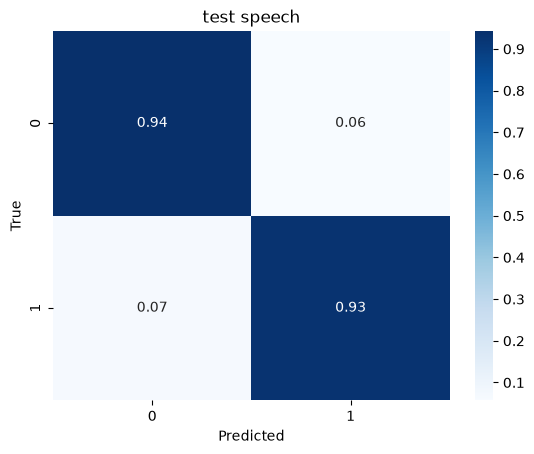

In [12]:
save_confusion_matrices(trainer, splits)